# Experiment B — Reconstructed Acceleration Through the Frozen Experiment A CNN

**Question:** how much of the representation learned from raw acceleration survives when the same frozen model is fed event-derived reconstructed acceleration?

Strict protocol:

1. Load the authoritative **Experiment A checkpoint**.
2. Reuse its exact **model weights, user split, `class_to_idx`, and raw-train normalization**.
3. Do **not** train or fine-tune the CNN on reconstruction.
4. Do **not** refit normalization on reconstruction.
5. Keep downstream references raw: raw train gallery, raw validation for kNN K selection, raw train prototypes, and raw train/validation for the linear probe.
6. Evaluate both matched held-out views with the same frozen feature extractor:
   - raw test → baseline/reference consistency,
   - reconstruction test → Experiment B.
7. Run paired raw/reconstruction embedding and prediction preservation diagnostics.
8. Use the same selected dataset roots as the A checkpoint; a root/action/sample mismatch must be resolved by regenerating A.

This notebook is intentionally thin. The executable workflow lives in `scripts/run_experiment_b.py`; reusable implementation lives in `snn/accel_reconstruction_eval/`.


In [33]:
from __future__ import annotations

from dataclasses import replace
import json
from pathlib import Path
import sys

import pandas as pd
import torch


def find_repository_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "scripts").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate repository root containing 'snn' and 'scripts'."
    )


REPOSITORY_ROOT = find_repository_root(Path.cwd())
SCRIPTS_DIR = REPOSITORY_ROOT / "scripts"

if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from snn.accel_reconstruction_eval import (
    checkpoint_random_seed,
    experiment_b_config,
    load_checkpoint,
)
from run_experiment_b import run_experiment_b

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)

print("Repository root:", REPOSITORY_ROOT)
print("CUDA available:", torch.cuda.is_available())


Repository root: /home/ted/project/writingring-viz
CUDA available: True


## Paths and runtime controls

`BASELINE_A_CHECKPOINT` is authoritative. Experiment B never updates it and never writes a replacement model checkpoint.

Regenerate Experiment A before running B/C/D whenever A's exclusions change. B has no local cohort or explicit-split override.


In [34]:
# Select the same one or two roots used to produce BASELINE_A_CHECKPOINT.
# Roots remain separate on disk and are combined only in the shared loader.
# The runner owns model/training logic; this is the only probe switch needed here.
PROBE_VARIANT = "cnn_m"  # one of: cnn_s, cnn_m, cnn_l
DATASET_ROOTS = [
    Path("outputs/action0_rectified_new_wavelets/low-pass/aligned-board-events"),
    Path("outputs/action1_rectified_new_wavelets/low-pass/aligned-board-events"),
]
BASELINE_A_CHECKPOINT = Path(
    "notebooks/artifacts/acceleration_cnn_representation/"
    f"{PROBE_VARIANT}/best_acceleration_cnn.pt"
)
OUTPUT_DIR = Path(
    "notebooks/artifacts/experiment_B_reconstruction_frozen_cnn"
)
if not BASELINE_A_CHECKPOINT.is_file() and PROBE_VARIANT == "cnn_l":
    BASELINE_A_CHECKPOINT = Path(
        "notebooks/artifacts/acceleration_cnn_representation/best_acceleration_cnn.pt"
    )

A_CHECKPOINT_PATH = (REPOSITORY_ROOT / BASELINE_A_CHECKPOINT).resolve()
A_CHECKPOINT = load_checkpoint(A_CHECKPOINT_PATH, map_location="cpu")
RANDOM_SEED = checkpoint_random_seed(
    A_CHECKPOINT,
    source=A_CHECKPOINT_PATH,
)
BATCH_SIZE = 128
NUM_WORKERS = 0
USE_GPU = True


## Build the Experiment B configuration

The domain contract is fixed:

- train/reference = raw,
- validation/reference = raw,
- test/query = reconstruction,
- normalization = loaded from the Experiment A checkpoint,
- CNN training = disabled.


In [35]:
config = experiment_b_config(
    baseline_checkpoint=BASELINE_A_CHECKPOINT,
    output_dir=OUTPUT_DIR,
    random_seed=RANDOM_SEED,
    probe_variant=PROBE_VARIANT,
)
config = replace(
    config,
    use_gpu=USE_GPU,
    loader=replace(
        config.loader,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
    ),
    evaluation=replace(
        config.evaluation,
        random_seed=RANDOM_SEED,
    ),
)
config.validate()
config.to_dict()


{'name': 'B_frozen_raw_to_reconstruction',
 'train_source': 'raw',
 'val_source': 'raw',
 'test_source': 'reconstruction',
 'normalization_source': 'checkpoint',
 'probe_variant': 'cnn_m',
 'training_enabled': False,
 'random_seed': 12345,
 'use_gpu': True,
 'normalization_chunk_segments': 256,
 'split': {'train_fraction': 0.7,
  'val_fraction': 0.15,
  'explicit_train_users': None,
  'explicit_val_users': None,
  'explicit_test_users': None,
  'require_all_users_assigned': True,
  'require_all_labels_in_all_splits': True,
  'excluded_users': (),
  'included_labels': None},
 'loader': {'batch_size': 128,
  'num_workers': 0,
  'pin_memory': None,
  'persistent_workers': None},
 'training': {'num_epochs': 30,
  'learning_rate': 0.0005,
  'weight_decay': 0.0,
  'use_class_weights': False,
  'early_stopping_patience': 10,
  'max_train_batches': None,
  'grad_clip_norm': None},
 'evaluation': {'k_values': (1, 3, 5, 10, 20, 50),
  'knn_k_candidates': (1, 3, 5, 7, 10, 15, 20),
  'similarity_q

## Run Experiment B

This call performs:

`load A checkpoint → validate reconstruction packages → recover A split/class mapping → load A normalization → strict frozen restore → raw/reconstruction embedding extraction → shared evaluation → paired preservation → save standardized artifacts`


In [36]:
run = run_experiment_b(
    root=DATASET_ROOTS,
    repository_root=REPOSITORY_ROOT,
    output_dir=OUTPUT_DIR,
    baseline_checkpoint=BASELINE_A_CHECKPOINT,
    config=config,
    probe_variant=PROBE_VARIANT,
)


Silhouette computed from 127 eligible samples across 12 classes.
Representation evaluation complete | CNN BA=0.2801 | kNN BA=0.2441 | Prototype BA=0.2735 | Linear probe BA=0.2719
Silhouette computed from 127 eligible samples across 12 classes.
Representation evaluation complete | CNN BA=0.2645 | kNN BA=0.2897 | Prototype BA=0.2305 | Linear probe BA=0.2702


## Inherited cohort provenance

Experiment B inherits this cohort from the authoritative A checkpoint; no user-cohort controls are defined locally.


In [37]:
provenance = json.loads(
    (run.output_dir / "provenance.json").read_text(encoding="utf-8")
)
display(
    pd.Series(
        {
            "cohort_source": provenance["cohort_source"],
            "excluded_users": provenance["excluded_users"],
            "eligible_users": provenance["eligible_users"],
            "train_users": provenance["train_users"],
            "val_users": provenance["val_users"],
            "test_users": provenance["test_users"],
            "class_to_idx": provenance["class_to_idx"],
        },
        name="Inherited cohort",
    )
)


cohort_source                                            checkpoint
excluded_users                                                   []
eligible_users    [user_0, user_1, user_2, user_3, user_4, user_...
train_users       [user_0, user_1, user_3, user_4, user_5, user_...
val_users                                [user_8, user_14, user_20]
test_users                               [user_2, user_13, user_16]
class_to_idx      {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'G': ...
Name: Inherited cohort, dtype: object

## Experiment B primary result

The root `summary.csv` corresponds to **reconstruction test through the frozen A model**.


In [38]:
display(run.summary.T.rename(columns={0: "Experiment B"}))


,Experiment B
CNN_test_balanced_accuracy,0.264520
CNN_test_accuracy,0.291339
CNN_test_macro_f1,0.193505
kNN_selected_k,15.000000
kNN_test_balanced_accuracy,0.289683
kNN_test_accuracy,0.299213
kNN_test_macro_f1,0.262046
prototype_test_balanced_accuracy,0.230550
prototype_test_accuracy,0.244094
prototype_test_macro_f1,0.179817


## Raw-test reference

This is the same frozen checkpoint and normalization evaluated on raw held-out test inputs. It should remain consistent with the standardized Experiment A result, up to deterministic numerical tolerance.


In [39]:
display(run.raw_reference_summary.T.rename(columns={0: "A raw reference"}))


,A raw reference
CNN_test_balanced_accuracy,0.280093
CNN_test_accuracy,0.299213
CNN_test_macro_f1,0.244228
kNN_selected_k,15.000000
kNN_test_balanced_accuracy,0.244108
kNN_test_accuracy,0.267717
kNN_test_macro_f1,0.209262
prototype_test_balanced_accuracy,0.273479
prototype_test_accuracy,0.275591
prototype_test_macro_f1,0.236051


## Raw vs reconstruction comparison


In [40]:
display(run.domain_comparison)


,A_raw_reference,B_raw_to_reconstruction
metric,,
CNN_test_balanced_accuracy,0.280093,0.264520
CNN_test_accuracy,0.299213,0.291339
CNN_test_macro_f1,0.244228,0.193505
kNN_selected_k,15.000000,15.000000
kNN_test_balanced_accuracy,0.244108,0.289683
kNN_test_accuracy,0.267717,0.299213
kNN_test_macro_f1,0.209262,0.262046
prototype_test_balanced_accuracy,0.273479,0.230550
prototype_test_accuracy,0.275591,0.244094


## Frozen-CNN classification across domains


In [41]:
display(run.classification_splits)


,accuracy,balanced_accuracy,macro_f1,weighted_f1,loss
split,,,,,
train_raw,0.385084,0.376901,0.364508,0.371069,1.804428
val_raw,0.480315,0.472258,0.460543,0.463363,1.756071
test_raw,0.299213,0.280093,0.244228,0.256125,2.372244
test_reconstruction,0.291339,0.264520,0.193505,0.213183,2.193089


## Split contract


In [42]:
display(run.split_summary)
display(run.label_split_counts)


,users,samples,labels
split,,,
train,14,657,12
val,3,127,12
test,3,127,12


split,train,val,test
label,,,
A,51,10,11
B,56,10,9
C,60,12,12
D,58,11,11
E,58,10,12
G,52,12,12
H,61,12,12
I,57,12,11
J,58,11,12


## Checkpoint normalization

These values are loaded from Experiment A; they are not re-estimated from reconstruction.


In [43]:
pd.DataFrame(
    {
        "channel": ["x", "y", "z"],
        "mean": run.normalization.mean,
        "std": run.normalization.std,
    }
).assign(
    fitted_on=run.normalization.fitted_on,
    valid_time_points=run.normalization.valid_time_points,
)


,channel,mean,std,fitted_on,valid_time_points
0,x,-0.692537,2.038793,raw:train,202358
1,y,0.173281,1.835576,raw:train,202358
2,z,0.202077,1.830725,raw:train,202358


## Paired raw/reconstruction preservation


In [44]:
display(run.paired_summary)
display(run.paired_transitions)


,mean_embedding_cosine_similarity,median_embedding_cosine_similarity,mean_embedding_cosine_distance,median_embedding_cosine_distance,prediction_agreement
0,0.94827,0.95899,0.05173,0.04101,0.519685


,transition,count,fraction
0,reference_wrong -> query_wrong,80,0.629921
1,reference_correct -> query_correct,28,0.220472
2,reference_correct -> query_wrong,10,0.078740
3,reference_wrong -> query_correct,9,0.070866


## Baseline checkpoint identity


In [45]:
pd.DataFrame(
    {
        "field": ["path", "sha256"],
        "value": [
            str(run.baseline_checkpoint_path),
            run.baseline_checkpoint_sha256,
        ],
    }
)


,field,value
0,path,/home/ted/project/writingring-viz/notebooks/ar...
1,sha256,cf9172d5044646c9249c2b4bec05f1772167b6d16c2ca9...


## Saved artifacts


In [46]:
artifact_table = pd.DataFrame(
    [
        {"artifact": name, "path": str(path)}
        for name, path in sorted(run.artifact_paths.items())
    ]
)
display(artifact_table)


,artifact,path
0,classification_splits,/home/ted/project/writingring-viz/notebooks/ar...
1,domain_comparison,/home/ted/project/writingring-viz/notebooks/ar...
2,embeddings_test_raw,/home/ted/project/writingring-viz/notebooks/ar...
3,embeddings_test_reconstruction,/home/ted/project/writingring-viz/notebooks/ar...
4,embeddings_train_raw,/home/ted/project/writingring-viz/notebooks/ar...
5,embeddings_val_raw,/home/ted/project/writingring-viz/notebooks/ar...
6,label_split_counts,/home/ted/project/writingring-viz/notebooks/ar...
7,paired_arrays,/home/ted/project/writingring-viz/notebooks/ar...
8,paired_per_class,/home/ted/project/writingring-viz/notebooks/ar...
9,paired_summary,/home/ted/project/writingring-viz/notebooks/ar...


# Visualization

The cells below are presentation-only. They consume the metrics and embeddings already generated by `run_experiment_b()`.

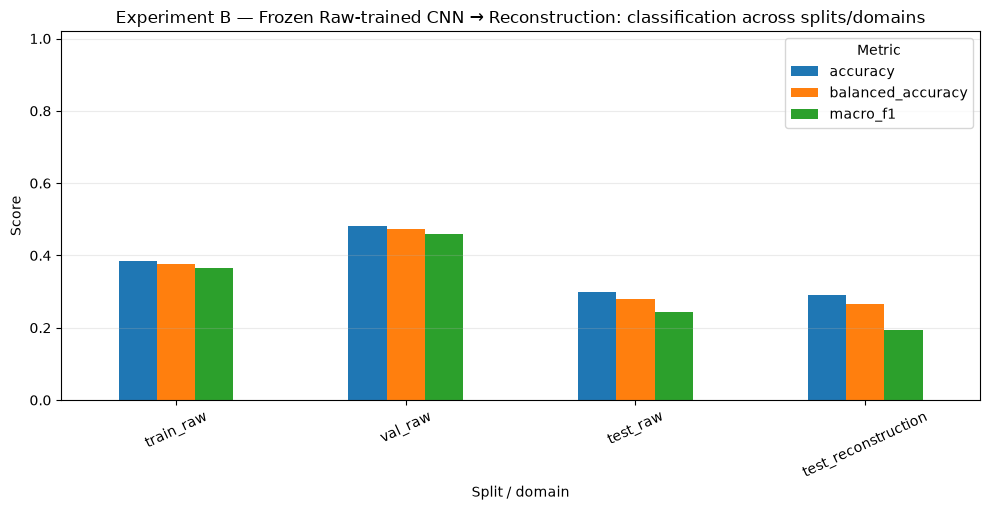

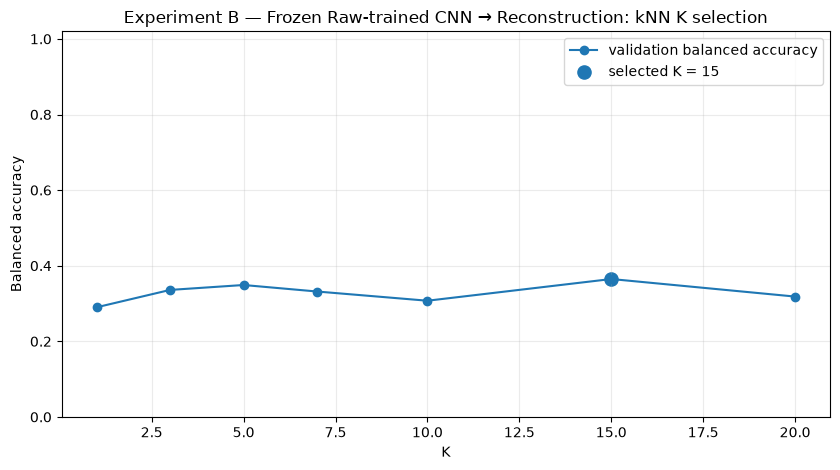

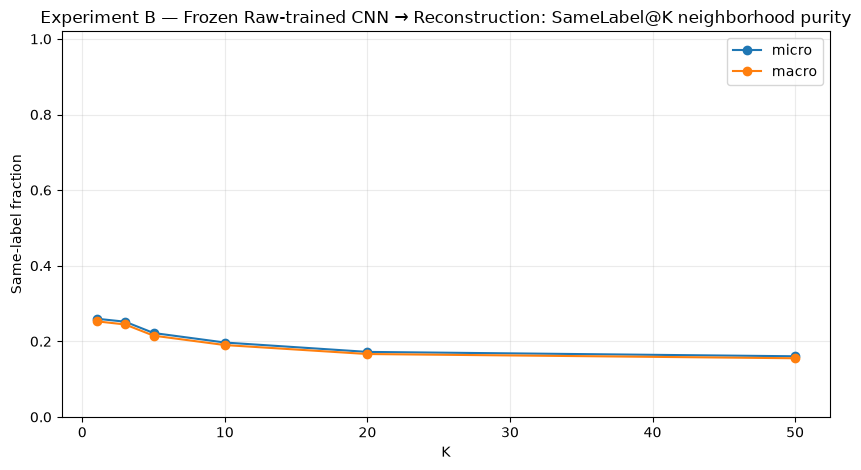

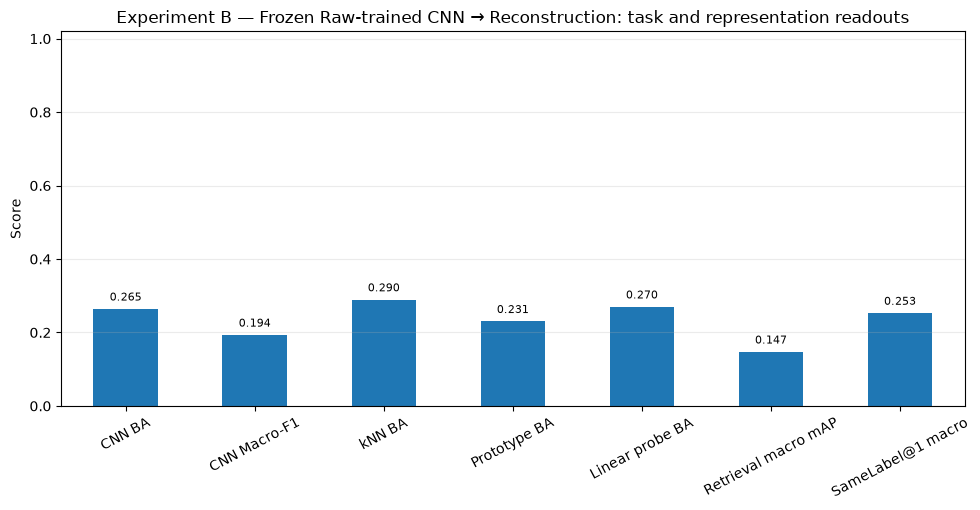

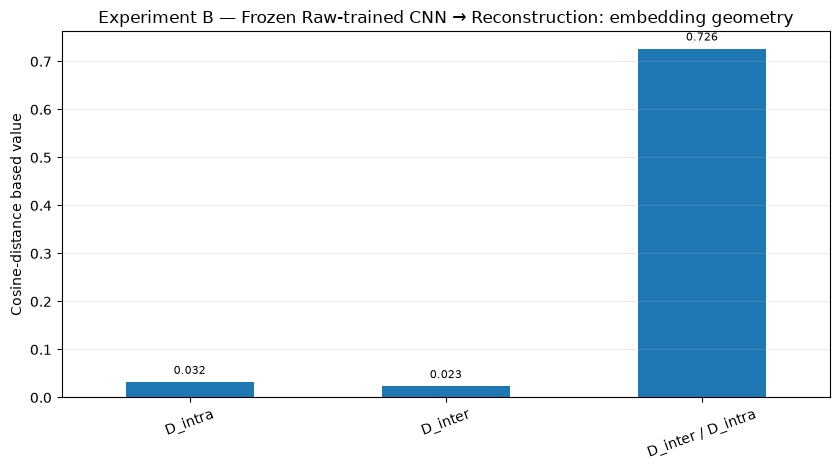

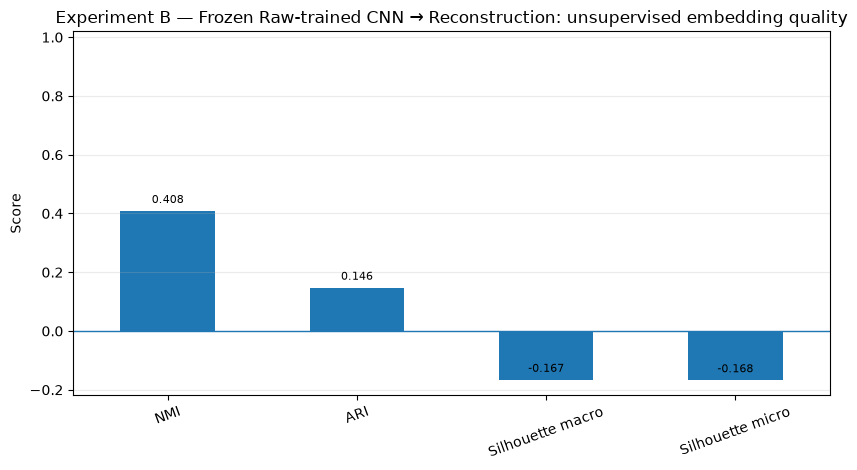

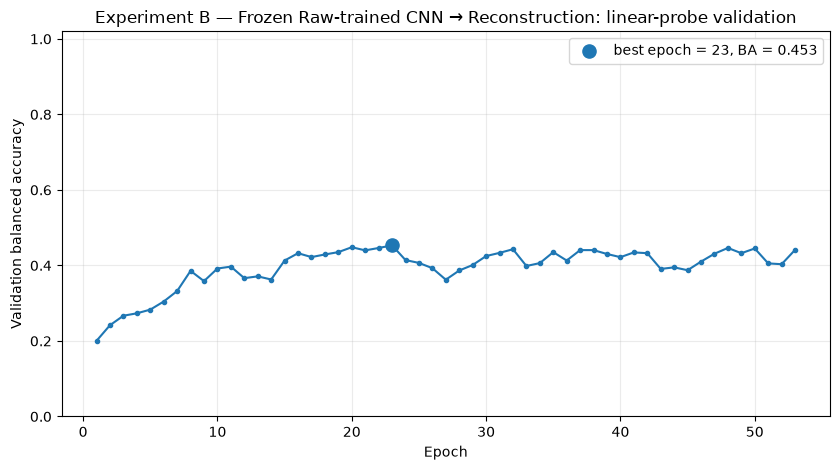

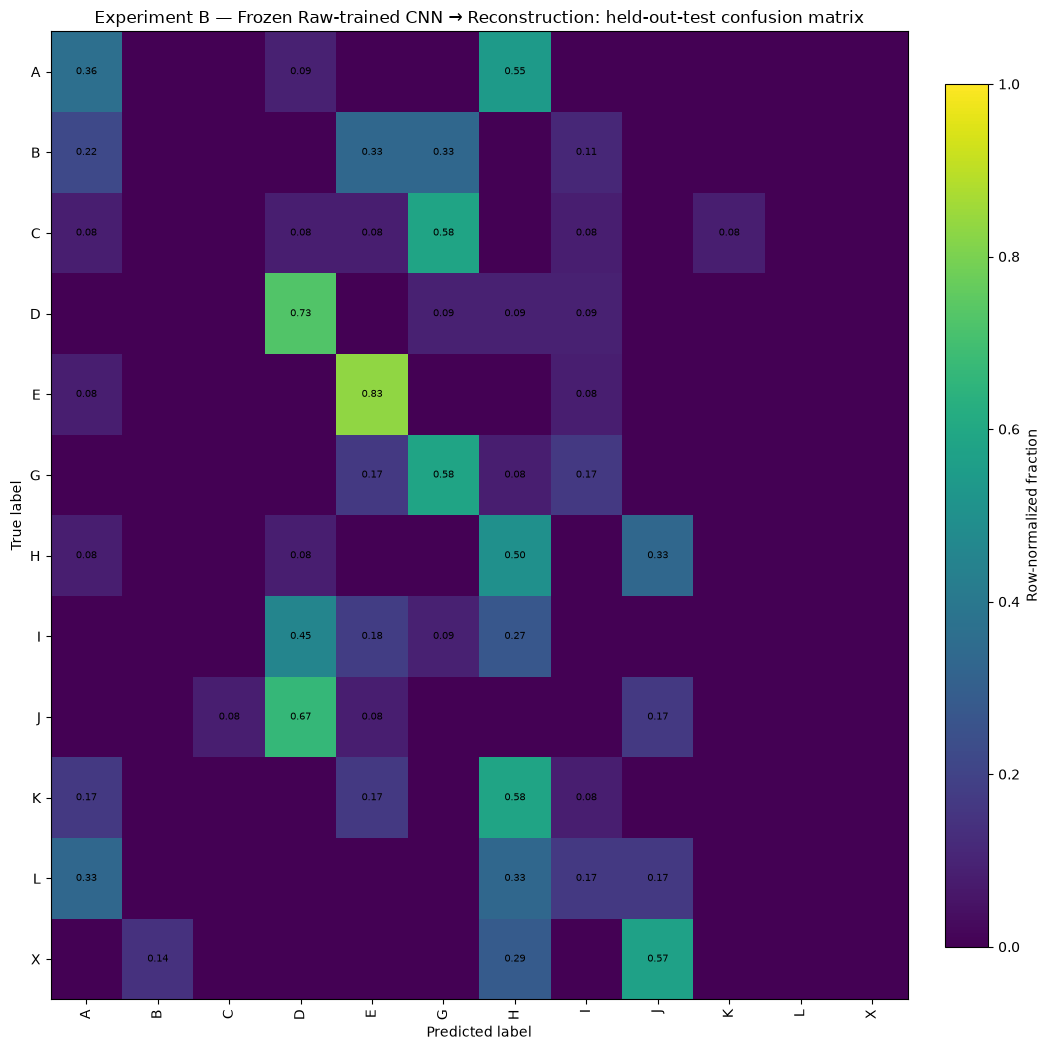

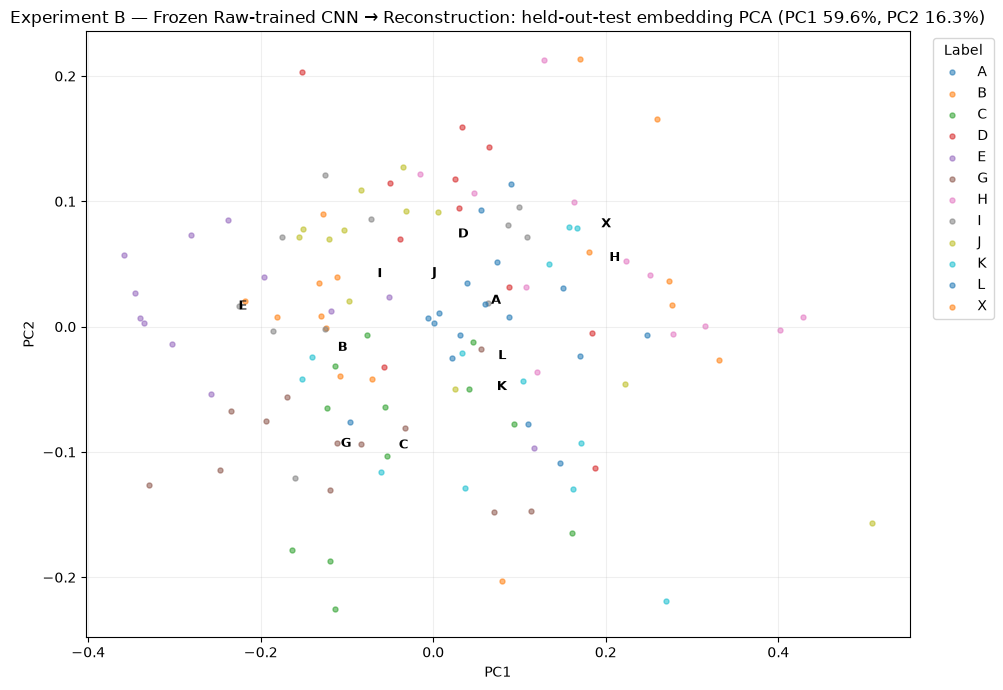

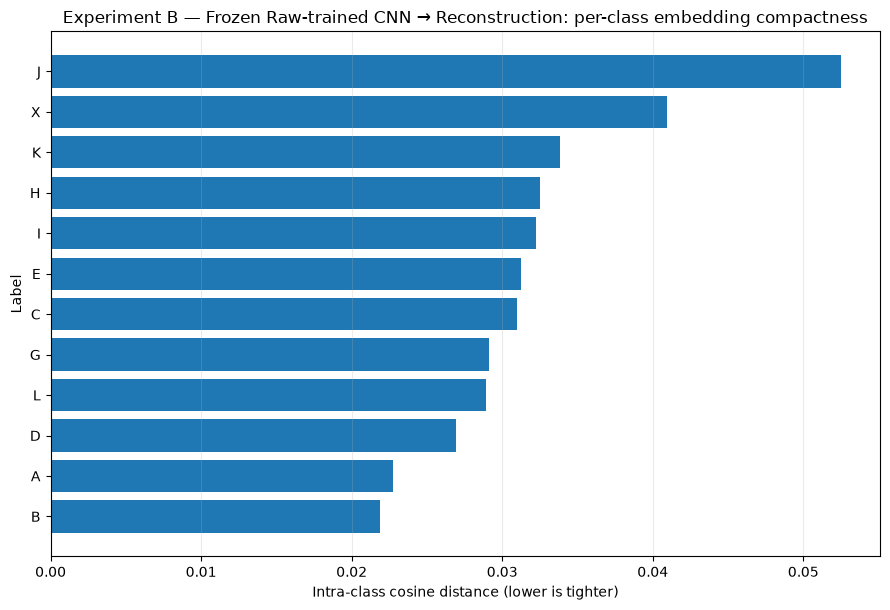

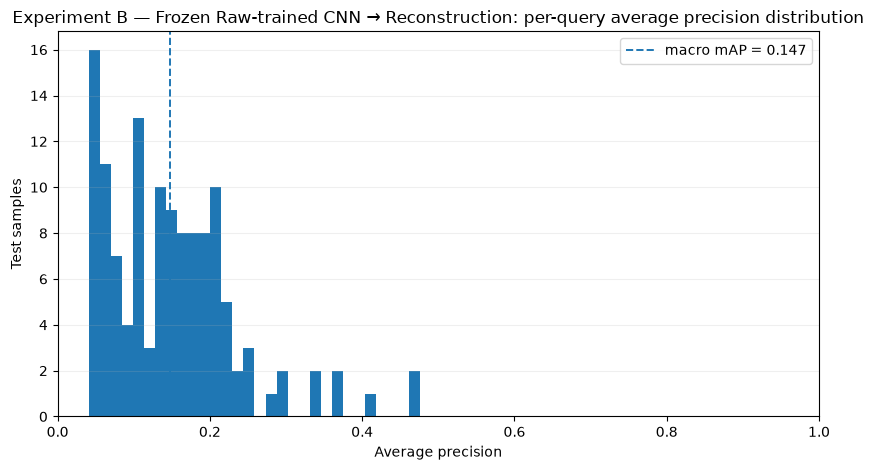

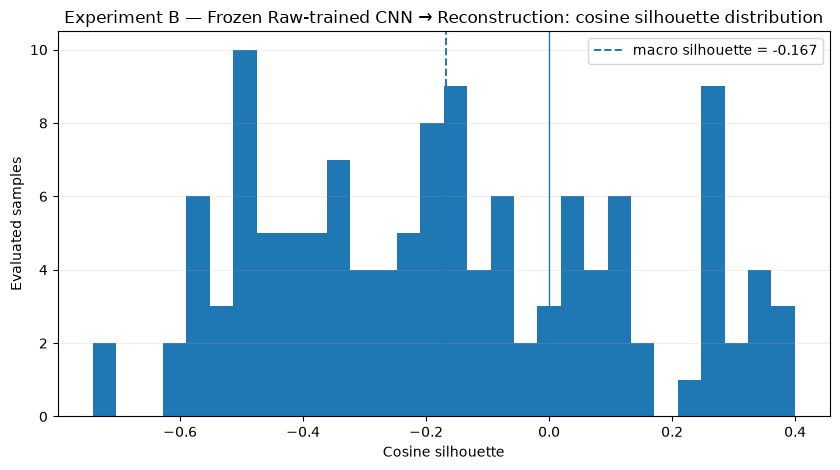

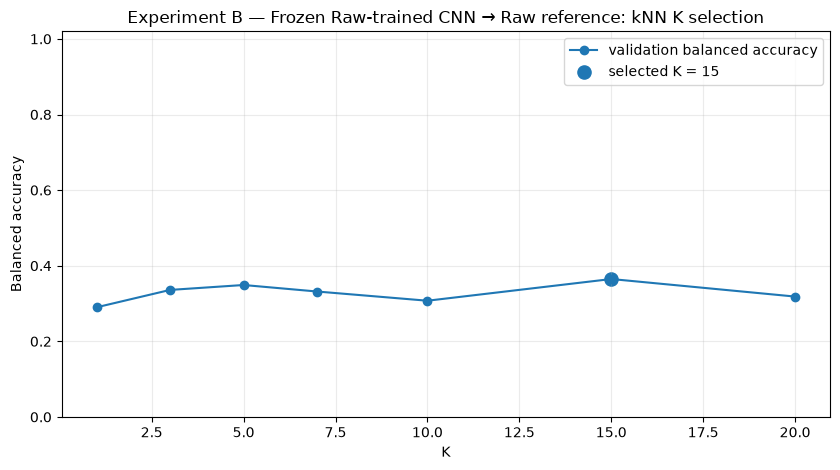

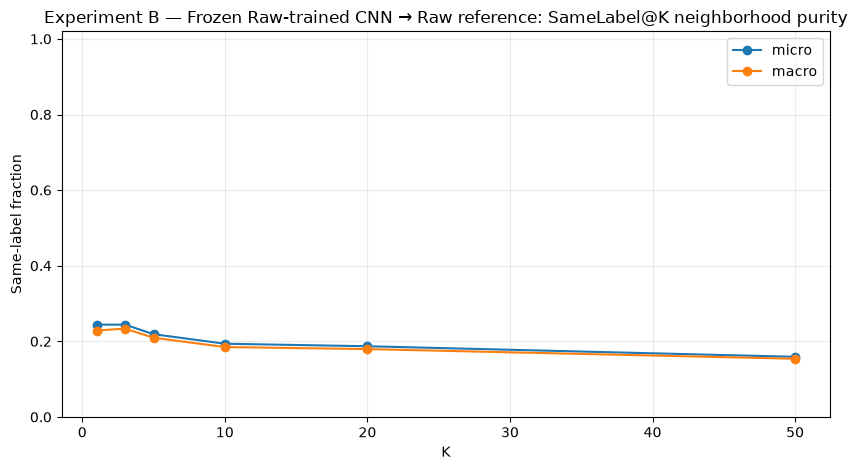

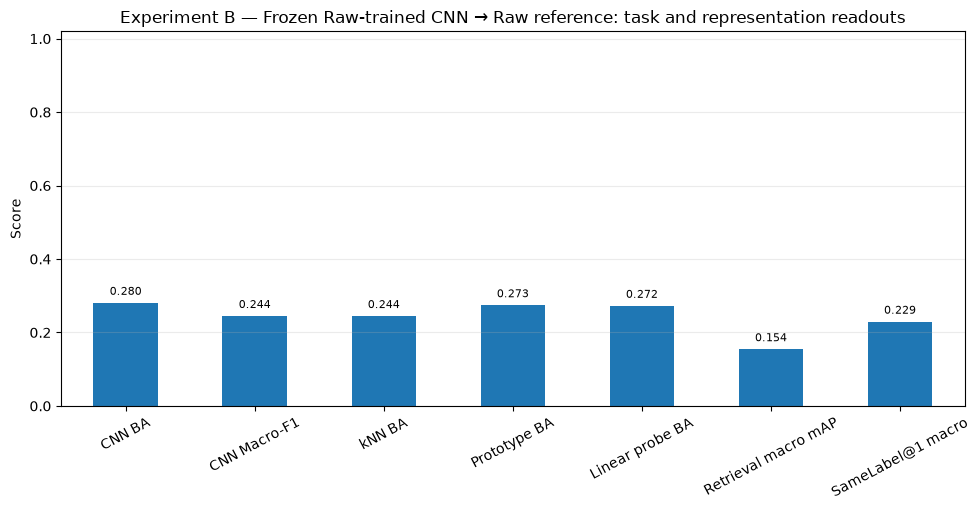

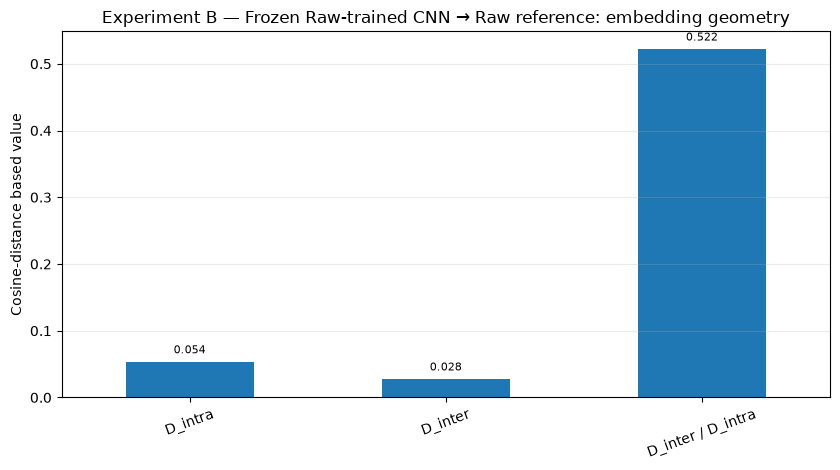

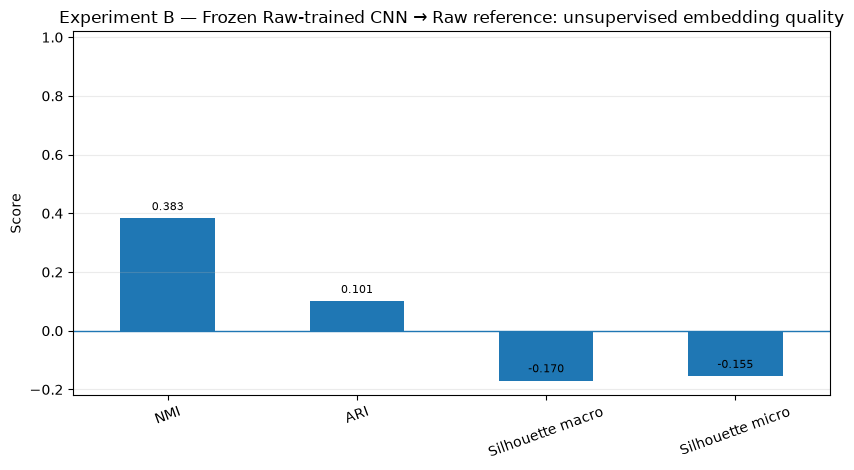

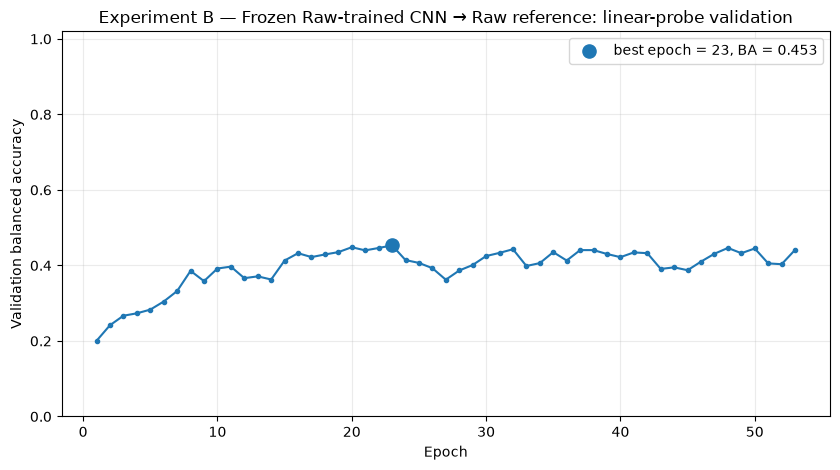

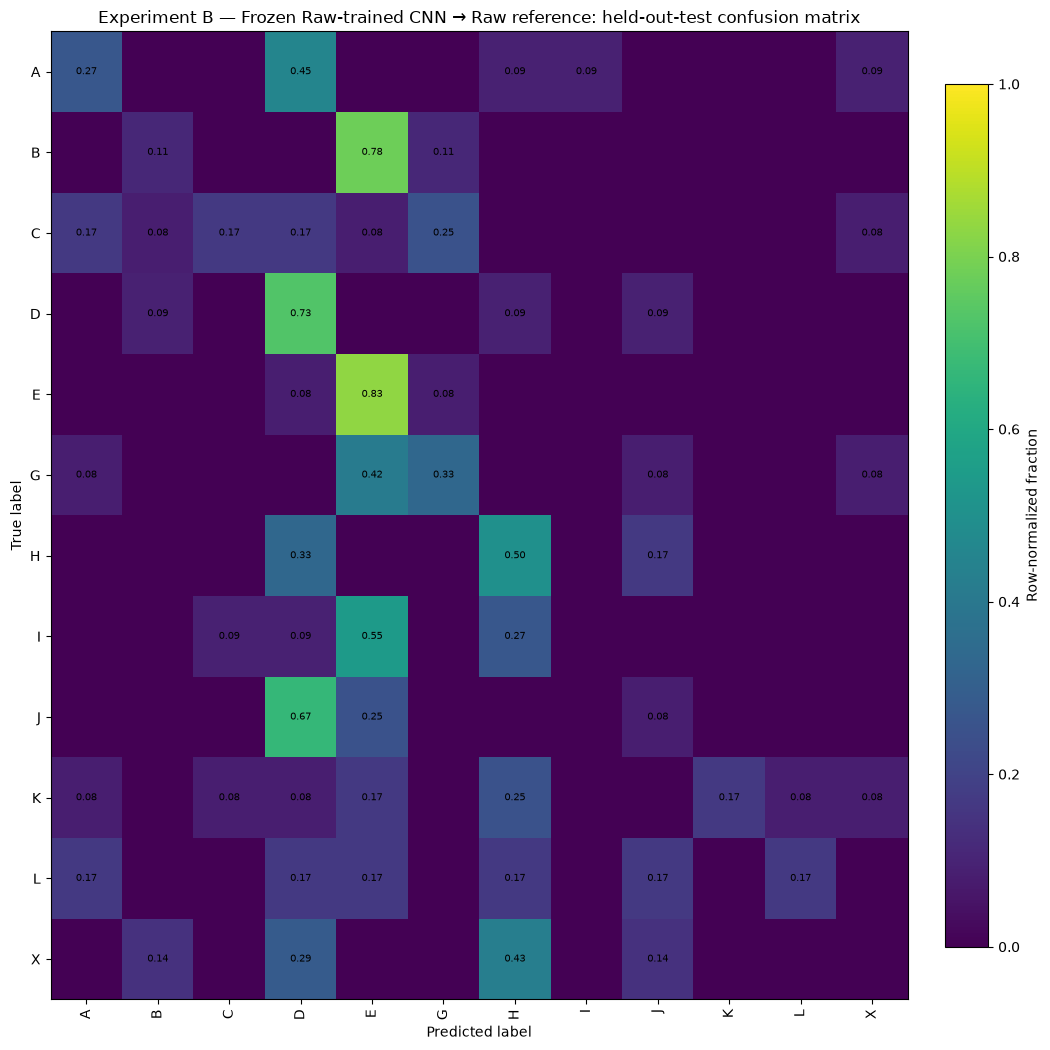

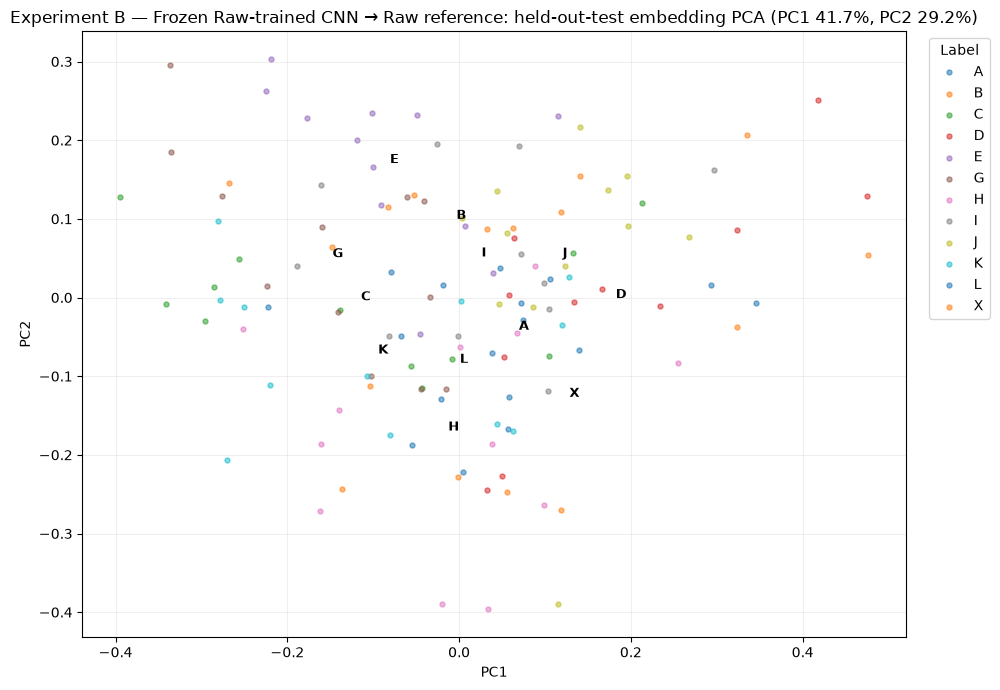

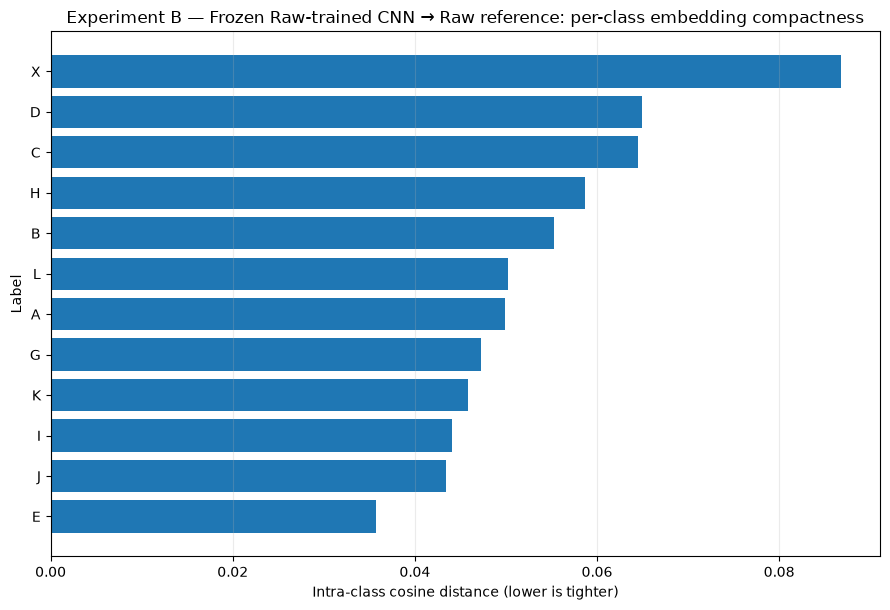

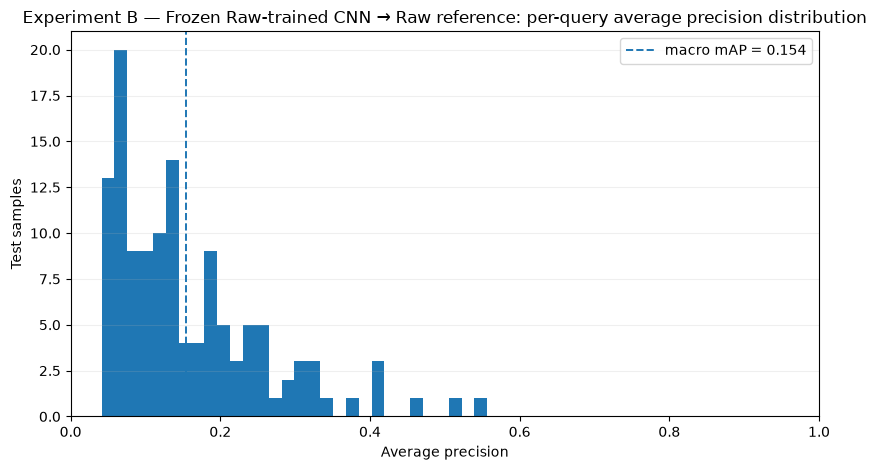

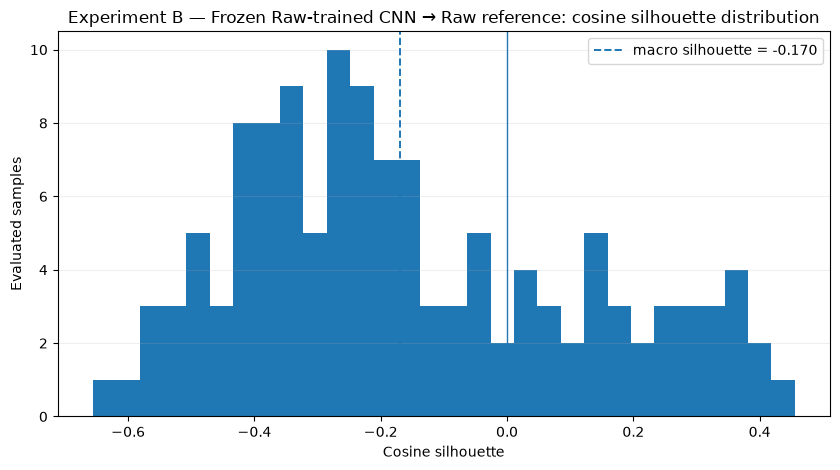

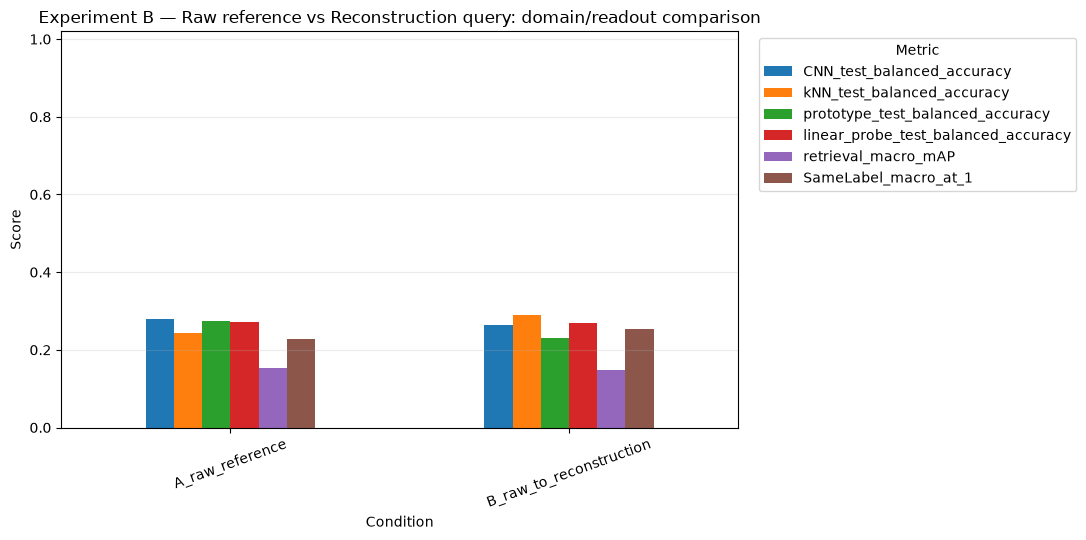

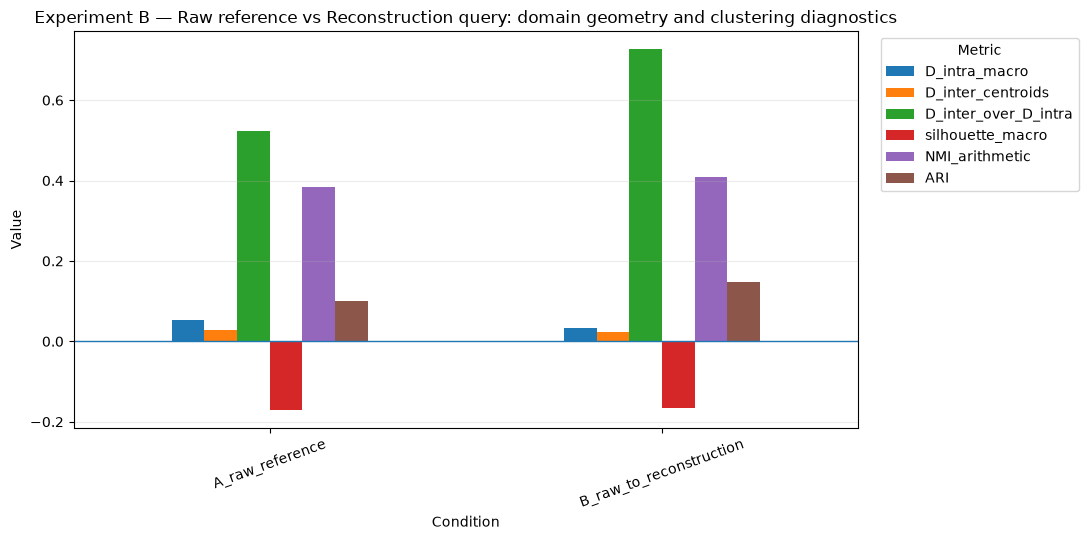

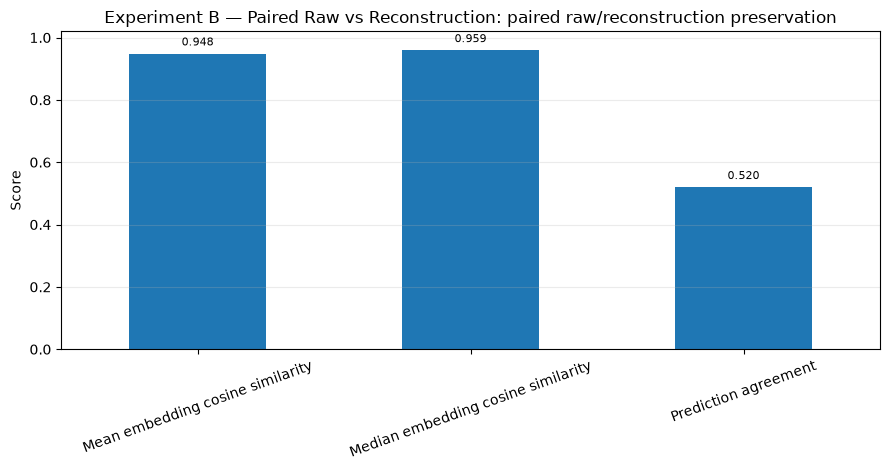

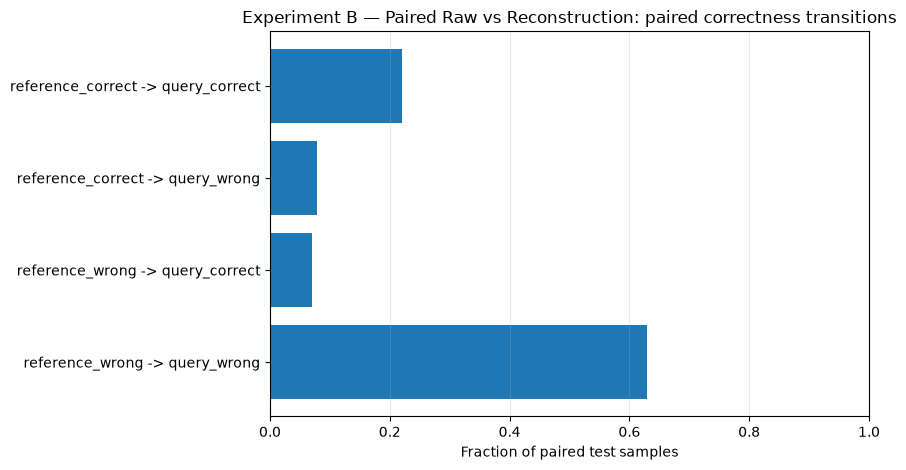

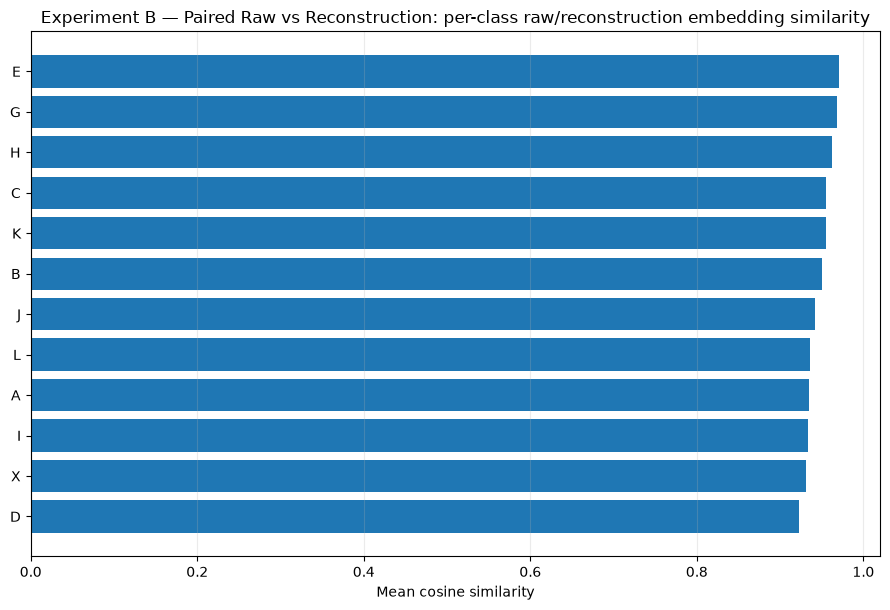

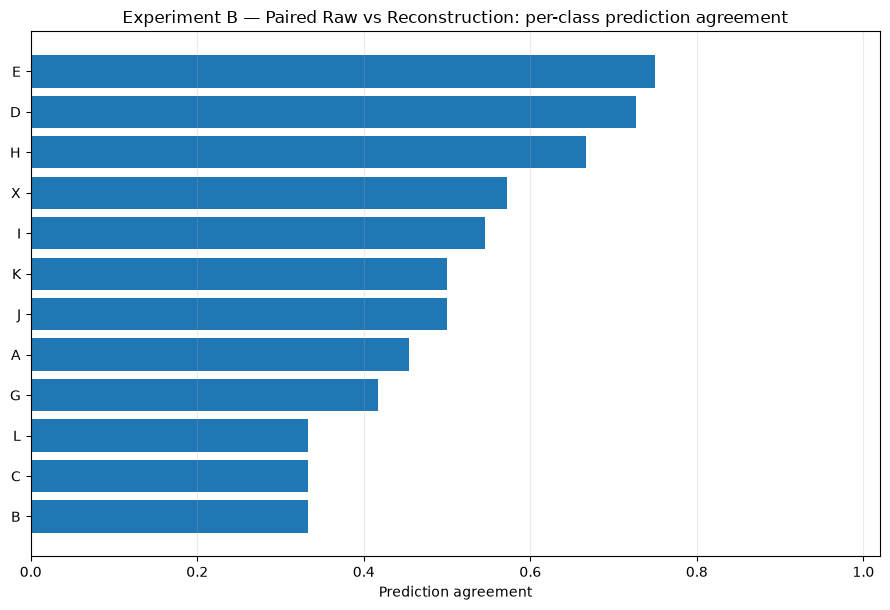

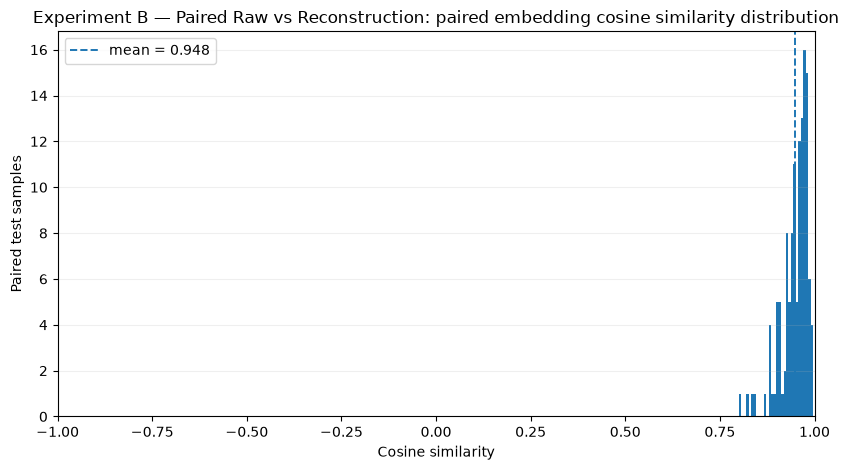

In [47]:
from snn.accel_reconstruction_eval.visualization import visualize_experiment_b

figures = visualize_experiment_b(run.output_dir)

## Interpretation

Use Experiment B together with A and C:

- **A high, B low, C ≈ A:** reconstructed acceleration still contains recoverable task information, but the raw-trained representation suffers domain shift.
- **A high, B low, C low:** reconstruction likely removes or strongly distorts task-relevant information.
- High paired embedding cosine similarity and prediction agreement support representation preservation; low values localize the raw→reconstruction change.
- Do not interpret a B accuracy drop alone as proof of information destruction, because B intentionally forbids adaptation to the reconstruction domain.
